In [1]:
'''
Process the XRD data for the quaternary samples.
'''
import numpy as np
import matplotlib.pyplot as plt
from pyhtp.xrd import XrdDatabase, ICSD
from pyhtp.typing import SampleInfo, AngleRange
from pyhtp.quaternary import scatter_quaternary


In [2]:
HEIGHT = 0.1

In [3]:

icsd = ICSD(file_dir='data/GSST ICSD')
sample1 = SampleInfo(
    name='GSTSe-2', element=['Ge', 'Sb', 'Se', 'Te'],
    angle_range=AngleRange(28, 52), temperature=350,
    film_thickness=[12.4, 7.6, 12.4, 7.6])
db = XrdDatabase(file_dir='data/GSTSe_XRD/GSTSe-2', info=sample1)
db = db.subtract_baseline(lam=500).smooth(window=201, factor=0.1)
c_peaks = db.characteristic_peak(height=HEIGHT)
print([round(peak, 2) for peak in c_peaks])
label = db.classify((3, 10), height=HEIGHT, full_run=True, verbose=0)
print(np.unique(label, return_counts=True))

[28.74, 30.65, 40.38, 43.2]
Classification with 2 clusters, silhouette score: 0.70
Classification with 3 clusters, silhouette score: 0.71
Classification with 4 clusters, silhouette score: 0.73
Classification with 5 clusters, silhouette score: 0.73
Classification with 6 clusters, silhouette score: 0.74
Classification with 7 clusters, silhouette score: 0.72
Classification with 8 clusters, silhouette score: 0.71
Finish with 4 clusters
(array([0, 1, 2, 3, 4, 5, 6]), array([ 16, 254,  47,  15,  16,  30,  22], dtype=int64))


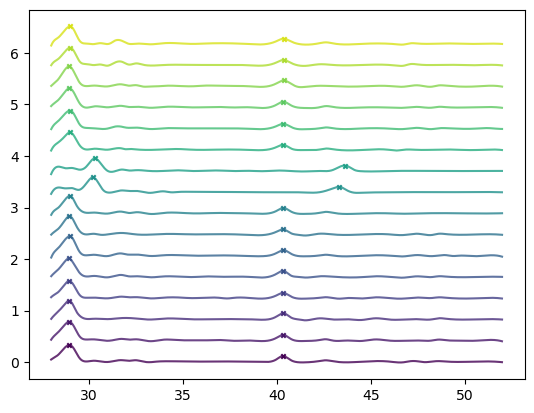

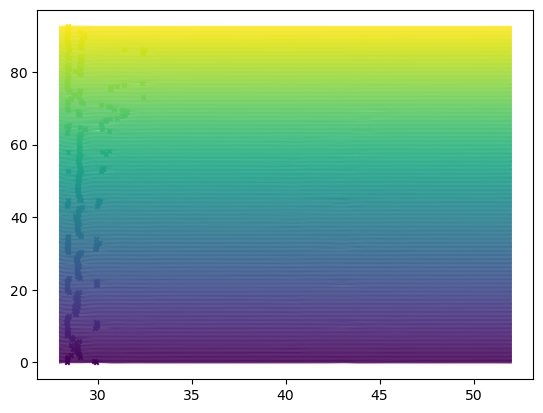

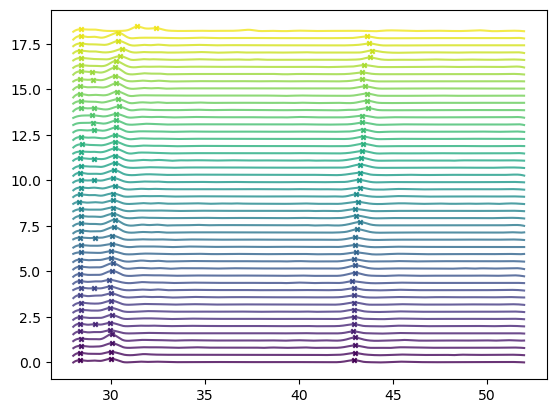

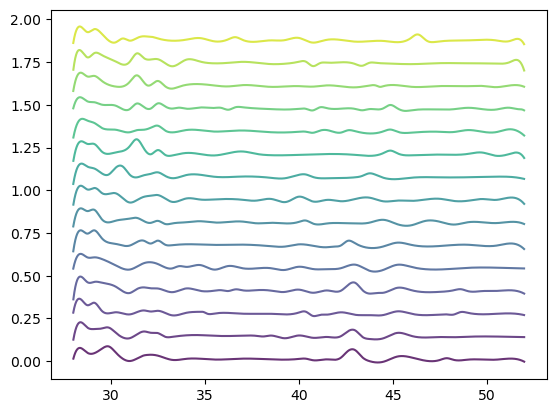

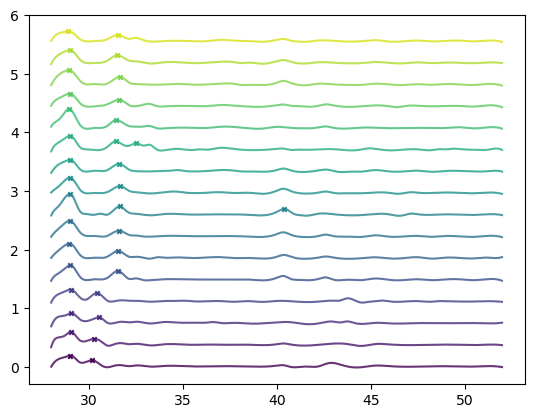

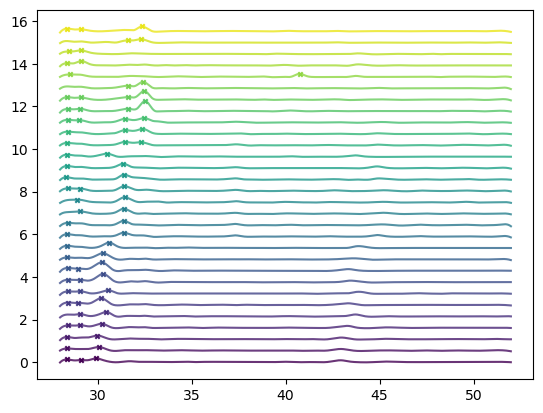

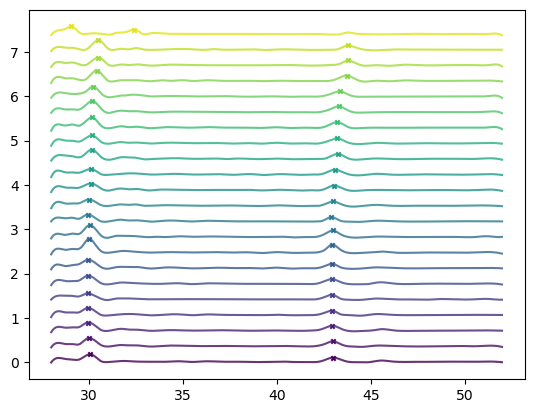

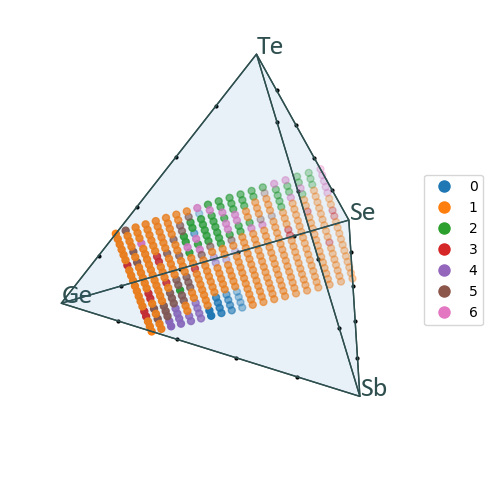

In [4]:
for i in range(len(np.unique(label))):
    db.plot(index=np.where(label == i)[0].tolist(), style='stack', height=HEIGHT)
scatter_quaternary(
    value=label, label=('Ge', 'Sb', 'Se', 'Te'),
    database=db, ticknum=5, path_type='snakelike')